# Brain Tumor MRI Image Classification

## Medical Image Classification using Transfer Learning (MobileNetV2)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
dataset_path = "../dataset"

print(os.listdir(dataset_path))

['Testing', 'Training']


In [3]:
train_path = os.path.join(dataset_path, "Training")
test_path = os.path.join(dataset_path, "Testing")

print("Training data:", os.listdir(train_path))
print("Testing data:", os.listdir(test_path))

Training data: ['glioma', 'meningioma', 'notumor', 'pituitary']
Testing data: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [4]:
classes = os.listdir(train_path)

print(classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
for cls in classes:
    folder = os.path.join(train_path,cls)
    print(f"{cls} : {len(os.listdir(folder))} images")

glioma : 1400 images
meningioma : 1400 images
notumor : 1400 images
pituitary : 1400 images


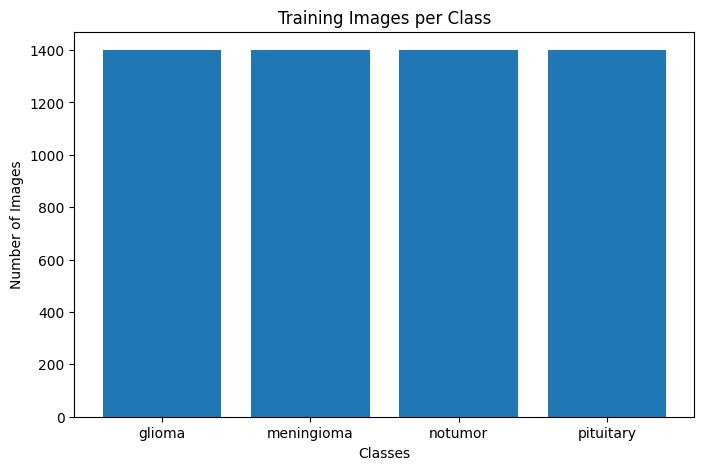

In [6]:
image_counts = []

for cls in classes:
    folder = os.path.join(train_path, cls)
    image_counts.append(len(os.listdir(folder)))
    
plt.figure(figsize=(8,5))
plt.bar(classes, image_counts)

plt.title("Training Images per Class")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

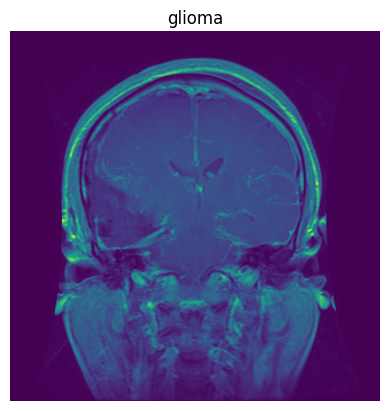

In [7]:
sample_class = classes[0]

sample_folder = os.path.join(train_path, sample_class)

sample_image = os.listdir(sample_folder)[0]

img = Image.open(os.path.join(sample_folder, sample_image))

plt.imshow(img)
plt.title(sample_class)
plt.axis("off")

plt.show()

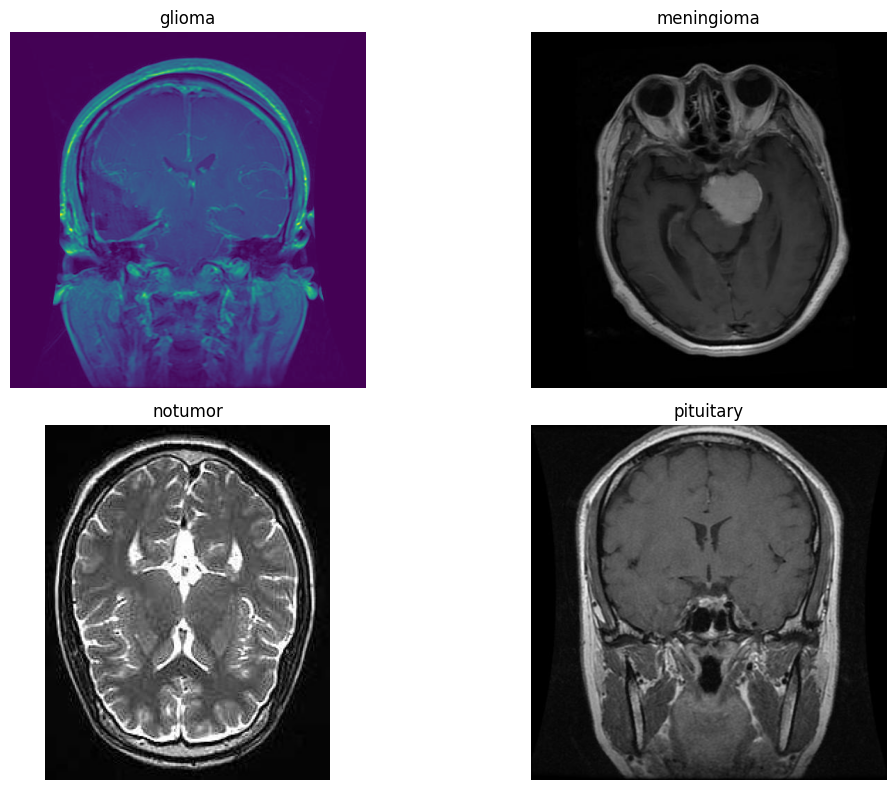

In [8]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    folder = os.path.join(train_path, cls)
    image_name = os.listdir(folder)[0]
    img = Image.open(os.path.join(folder, image_name))
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    
plt.tight_layout()
plt.show()

In [9]:
for cls in classes:
    folder = os.path.join(train_path, cls)
    image_name = os.listdir(folder)[0]
    img = Image.open(os.path.join(folder, image_name))
    print(cls,":", img.size)

glioma : (512, 512)
meningioma : (512, 512)
notumor : (201, 251)
pituitary : (512, 512)


# Image Preprocessing and Data Augmentation

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [11]:
# Dataset paths
train_dir = "../dataset/Training"
test_dir = "../dataset/Testing"

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Training Folder :", train_dir)
print("Testing Folder :", test_dir)
print("Image Size :", IMG_SIZE)
print("Batch Size :", BATCH_SIZE)

Training Folder : ../dataset/Training
Testing Folder : ../dataset/Testing
Image Size : (224, 224)
Batch Size : 32


In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

print("ImageDataGenerator created Successfully!")

ImageDataGenerator created Successfully!


In [13]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
    
)

Found 4480 images belonging to 4 classes.


In [14]:
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=True
)

Found 1120 images belonging to 4 classes.


In [15]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 1600 images belonging to 4 classes.


In [16]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [17]:
images, labels = next(train_generator)

print("Images Shape:", images.shape)
print("Labels Shape:", labels.shape)

Images Shape: (32, 224, 224, 3)
Labels Shape: (32, 4)


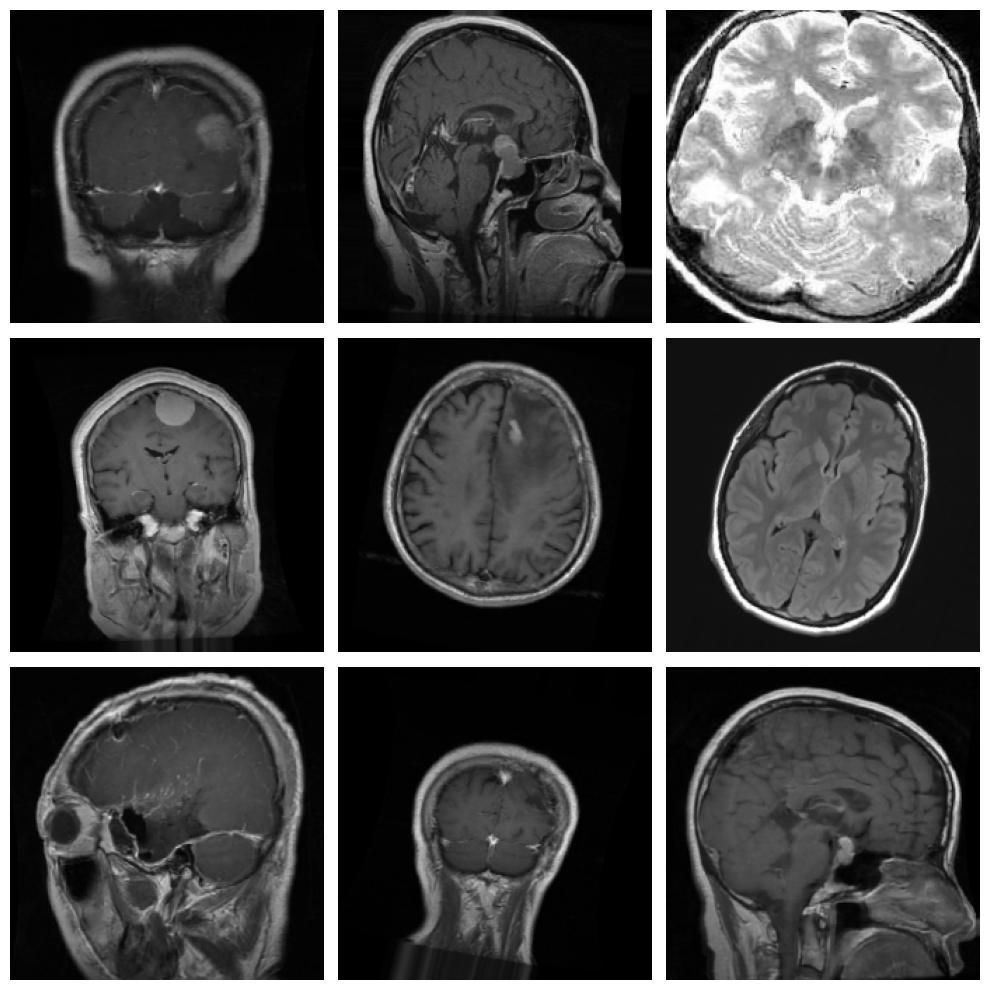

In [18]:
# Display processed images
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [20]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, GlobalAveragePooling2D

In [21]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print("MobileNetV2 Loaded Successfully!")

MobileNetV2 Loaded Successfully!


In [22]:
base_model.trainable = False
print("Base Model Frozen")

Base Model Frozen


In [23]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(4, activation='softmax')(x)

In [24]:
model = Model(inputs=base_model.input, outputs=predictions)

print("Model Created Successfully!")

Model Created Successfully!


In [25]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model Compiled Successfully!")

Model Compiled Successfully!


In [26]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
print("Training layers:", len(model.trainable_variables))

Training layers: 4


In [28]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [29]:
checkpoint = ModelCheckpoint(
    "../models/brain_tumor_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Callbacks Created Successfully!")

Callbacks Created Successfully!


In [30]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.6735 - loss: 0.8444
Epoch 1: val_accuracy improved from None to 0.86518, saving model to ../models/brain_tumor_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 132s 917ms/step - accuracy: 0.7679 - loss: 0.6114 - val_accuracy: 0.8652 - val_loss: 0.3577
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.8420 - loss: 0.4147
Epoch 2: val_accuracy improved from 0.86518 to 0.88214, saving model to ../models/brain_tumor_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 129s 923ms/step - accuracy: 0.8469 - loss: 0.4081 - val_accuracy: 0.8821 - val_loss: 0.3058
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.8578 - loss: 0.3654
Epoch 3: val_accuracy improved from 0.88214 to 0.89018, saving model to ../models/brain_tumor_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 118s 844ms/step - accuracy: 0.8650 - loss: 0.3559 - val_accuracy: 0.8902 - val_loss: 0.3136
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - ac

In [31]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


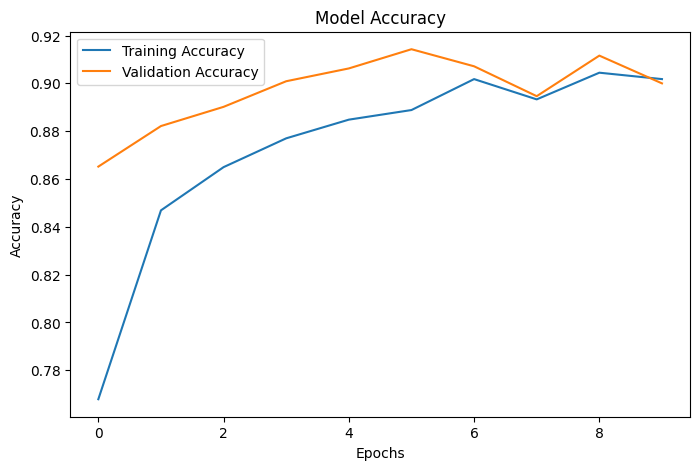

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

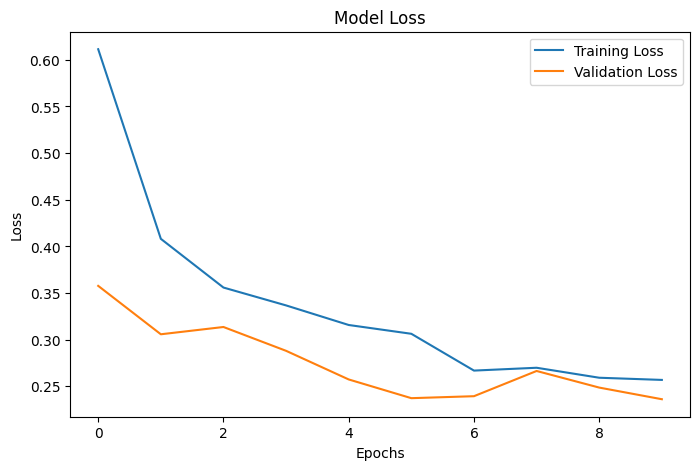

In [35]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [36]:
import os 

print(os.listdir("../models"))

['brain_tumor_model.keras', 'final_brain_tumor_model.keras']


In [37]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 531ms/step - accuracy: 0.8288 - loss: 0.5610
Test Loss : 0.5610172748565674
Test Accuracy : 0.8287500143051147


In [38]:
# Predict test images
predictions = model.predict(test_generator)

print(predictions.shape)

50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 490ms/step
(1600, 4)


In [39]:
import numpy as np

predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes[:10])

[1 0 0 0 3 1 1 0 1 0]


In [40]:
true_classes = test_generator.classes

print(true_classes[:10])

[0 0 0 0 0 0 0 0 0 0]


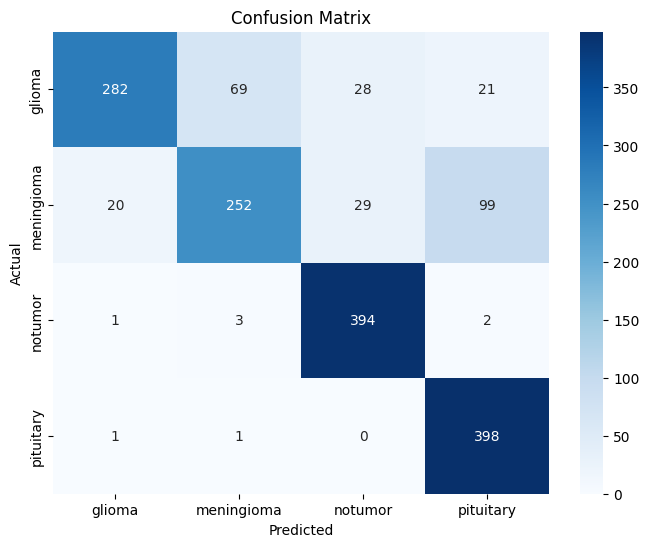

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [44]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=test_generator.class_indices.keys()
    )
)


              precision    recall  f1-score   support

      glioma       0.93      0.70      0.80       400
  meningioma       0.78      0.63      0.70       400
     notumor       0.87      0.98      0.93       400
   pituitary       0.77      0.99      0.87       400

    accuracy                           0.83      1600
   macro avg       0.84      0.83      0.82      1600
weighted avg       0.84      0.83      0.82      1600



In [47]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "../sample_images/test.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class :", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
Predicted Class : glioma


In [48]:
model.save("../models/final_brain_tumor_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [49]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nModels folder contents:")
print(os.listdir("../models"))

Current Working Directory:
c:\Users\VICTUS\Desktop\Medical_Image_Classification\notebooks

Models folder contents:
['brain_tumor_model.keras', 'final_brain_tumor_model.keras']
